# 📊 VaccineNLP — Model Benchmark Report

**Notebook tổng hợp & so sánh 3 mô hình** · Taxonomy v3 · Gold Test Set n=186

---

## ⚙️ HƯỚNG DẪN WIRING TRÊN KAGGLE (đọc kỹ trước khi chạy)

Notebook này **không tự train** — nó chỉ đọc kết quả JSON từ 3 notebook model.
Trên Kaggle, mỗi notebook chạy độc lập nên cần wiring thủ công:

### Bước 1 — Chạy 3 notebook model (theo thứ tự bất kỳ)
| Notebook | File output (ở `/kaggle/working/`) |
|---|---|
| `vaccinenlp-phobert-v2-multitask-classifier` | `phobert_v2_results.json` |
| `vaccinenlp-xlm-r-v1-multitask-classifier`   | `xlmr_v1_results.json` |
| `vaccinenlp-gemma-4-qlora-multitask`         | `gemma_v3_results.json` + `gemma_inference_results_v3.jsonl` |

Mỗi notebook → **Save Version** → chờ commit xong (status: Complete).

### Bước 2 — Add 3 notebook output làm Input cho notebook này
Sidebar phải → **+ Add Input** → tab **Notebook Output** →
add lần lượt cả 3 notebook ở Bước 1.
Sau khi add, file sẽ xuất hiện tại `/kaggle/input/<notebook-slug>/...`

### Bước 3 — Run All
Notebook tự động tìm 3 file JSON. Nếu thiếu notebook nào, nó dùng
**FALLBACK** (số liệu đã xác nhận 17/05/2026) và báo rõ nguồn.

> ⚠️ Nếu bảng hiển thị `[Fallback]` cho model nào → notebook đó chưa
> được add làm input, hoặc chưa Save Version thành công.

---


In [1]:
import datetime
# VaccineNLP — Model Benchmark Report
# Auto-generated comparison: PhoBERT-v2 | XLM-R-v1 | Gemma-4 4B
# Taxonomy v3: Misinfo(2) | Stance(3) | Sentiment(3)
# Gold Test Set: 186 samples (Human-validated, HUPH 2026)

import os, json, glob
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix

# ── Taxonomy v3 ──────────────────────────────────────────────────────────
N_CLASSES = {'misinfo': 2, 'stance': 3, 'sentiment': 3}
HC_NAMES  = {
    'misinfo':   ['Tin giả',   'Chính xác'],
    'stance':    ['Ủng hộ',    'Phản đối',   'Trung lập'],
    'sentiment': ['Tiêu cực',  'Trung tính',  'Tích cực'],
}
TASKS     = list(N_CLASSES.keys())
MODEL_DISPLAY = {
    'phobert': 'PhoBERT-v2',
    'xlmr':    'XLM-R-v1',
    'gemma':   'Gemma-4 4B (XAI)',
}
REPORT_DIR = '/kaggle/working/benchmark_report'
os.makedirs(REPORT_DIR, exist_ok=True)
print("✅ Config loaded — Taxonomy v3")

✅ Config loaded — Taxonomy v3


In [2]:
# ── Robust cross-notebook loader (INTEROP CONTRACT) ──────────────────────
# Tìm 3 file JSON theo TÊN DUY NHẤT, recursive across cả /kaggle/input và
# /kaggle/working. Ưu tiên file mới nhất nếu có nhiều bản.

def find_result(unique_name):
    """Tìm file JSON theo tên duy nhất ở mọi nơi Kaggle có thể mount."""
    candidates = []
    for root in ('/kaggle/input', '/kaggle/working'):
        candidates += glob.glob(f'{root}/**/{unique_name}', recursive=True)
    if not candidates:
        return None, None
    # Ưu tiên file mtime mới nhất (lần chạy gần nhất)
    candidates.sort(key=lambda p: os.path.getmtime(p), reverse=True)
    best = candidates[0]
    try:
        with open(best, encoding='utf-8') as f:
            return json.load(f), best
    except Exception as e:
        print(f"⚠️  Lỗi đọc {best}: {e}")
        return None, None

# FALLBACK — số liệu đã xác nhận (chạy thật 17/05/2026, Taxonomy v3)
FALLBACK = {
    'phobert': {
        'model':'phobert-v2','timestamp':'2026-05-17 (fallback)',
        'misinfo':   {'macro_f1':0.6886,'per_class':[0.4933,0.8839],'support':[28,158]},
        'stance':    {'macro_f1':0.6383,'per_class':[0.5817,0.6316,0.6923],'support':[54,48,84]},
        'sentiment': {'macro_f1':0.7289,'per_class':[0.7606,0.7671,0.6600],'support':[71,75,40]},
    },
    'xlmr': {
        'model':'xlmr-base','timestamp':'2026-05-17 (fallback)',
        'misinfo':   {'macro_f1':0.6632,'per_class':[0.4478,0.8785],'support':[28,158]},
        'stance':    {'macro_f1':0.5618,'per_class':[0.4706,0.5660,0.6489],'support':[54,48,84]},
        'sentiment': {'macro_f1':0.6394,'per_class':[0.6993,0.6618,0.5571],'support':[71,75,40]},
    },
    'gemma': {
        'model':'gemma-4-4b-xai','timestamp':'2026-05-17 (fallback)',
        'misinfo':   {'macro_f1':0.3588,'per_class':[0.3429,0.3747],'support':[28,158]},
        'stance':    {'macro_f1':0.2862,'per_class':[0.5660,0.3721,0.5106],'support':[54,48,84]},
        'sentiment': {'macro_f1':0.2883,'per_class':[0.5623,0.1579,0.0247],'support':[71,75,40]},
    },
}

UNIQUE_NAMES = {
    'phobert': 'phobert_v2_results.json',
    'xlmr':    'xlmr_v1_results.json',
    'gemma':   'gemma_v3_results.json',
}

results, sources = {}, {}
print("="*60)
print("  DATA SOURCE RESOLUTION")
print("="*60)
for key, fname in UNIQUE_NAMES.items():
    res, path = find_result(fname)
    if res and all(t in res for t in ('misinfo','stance','sentiment')):
        results[key] = res
        sources[key] = f"LIVE  ← {path}"
    else:
        results[key] = FALLBACK[key]
        sources[key] = f"FALLBACK (file '{fname}' không tìm thấy)"
    flag = "✅" if "LIVE" in sources[key] else "⚠️ "
    print(f"  {flag} {MODEL_DISPLAY[key]:<20}: {sources[key]}")
print("="*60)

n_live = sum(1 for s in sources.values() if 'LIVE' in s)
if n_live < 3:
    print(f"\n⚠️  CHỈ {n_live}/3 model có kết quả LIVE.")
    print("   → Kiểm tra: đã Save Version + Add Notebook Output làm input chưa?")
else:
    print(f"\n✅ Cả 3 model đều LIVE — báo cáo phản ánh kết quả thực.")


  DATA SOURCE RESOLUTION
  ✅ PhoBERT-v2          : LIVE  ← /kaggle/input/notebooks/kimmnhhng/vaccinenlp-phobert-v2-multitask-classifier/phobert_v2/phobert_v2_results.json
  ✅ XLM-R-v1            : LIVE  ← /kaggle/input/notebooks/kimmnhhng/vaccinenlp-xlm-r-v1-multitask-classifier/xlmr_v1/xlmr_v1_results.json
  ✅ Gemma-4 4B (XAI)    : LIVE  ← /kaggle/input/notebooks/kimmnhhng/03b-vaccinenlp-gemma-4-inference/gemma_v3_results.json

✅ Cả 3 model đều LIVE — báo cáo phản ánh kết quả thực.


In [3]:
# ── Bảng Macro F1 tổng hợp ────────────────────────────────────────────
ORDER = ['xlmr', 'phobert', 'gemma']

print("=" * 72)
print("  BENCHMARK — Macro F1 (Gold Test Set, n=186)")
print("  Taxonomy v3: Misinfo(2cls) | Stance(3cls) | Sentiment(3cls)")
print("=" * 72)
print(f"  {'Mô hình':<24} {'Misinfo':>9} {'Stance':>9} {'Sentiment':>11} {'TB':>8}")
print("-" * 72)
for k in ORDER:
    r   = results[k]
    m   = r['misinfo']['macro_f1']
    st  = r['stance']['macro_f1']
    se  = r['sentiment']['macro_f1']
    avg = round((m + st + se) / 3, 4)
    name = MODEL_DISPLAY[k]
    print(f"  {name:<24} {m:>9.4f} {st:>9.4f} {se:>11.4f} {avg:>8.4f}")
print("=" * 72)

# Best per task
print("\n  Best per task:")
for task in TASKS:
    best_k = max(ORDER, key=lambda k: results[k][task]['macro_f1'])
    best_v = results[best_k][task]['macro_f1']
    print(f"  {task:<12}: {MODEL_DISPLAY[best_k]} ({best_v:.4f}) ✅")

  BENCHMARK — Macro F1 (Gold Test Set, n=186)
  Taxonomy v3: Misinfo(2cls) | Stance(3cls) | Sentiment(3cls)
  Mô hình                    Misinfo    Stance   Sentiment       TB
------------------------------------------------------------------------
  XLM-R-v1                    0.7038    0.6224      0.6866   0.6709
  PhoBERT-v2                  0.6996    0.6640      0.7266   0.6967
  Gemma-4 4B (XAI)            0.6377    0.6264      0.7700   0.6780

  Best per task:
  misinfo     : XLM-R-v1 (0.7038) ✅
  stance      : PhoBERT-v2 (0.6640) ✅
  sentiment   : Gemma-4 4B (XAI) (0.7700) ✅


In [4]:
# ── Per-class F1 breakdown ────────────────────────────────────────────
print("=" * 72)
print("  PER-CLASS F1 — Gold Test Set (n=186), Taxonomy v3")
print("=" * 72)

model_names = [MODEL_DISPLAY[k] for k in ORDER]
for task in TASKS:
    labels = HC_NAMES[task]
    print(f"\n  {task.upper()} (Macro: " +
          " | ".join(f"{MODEL_DISPLAY[k]}={results[k][task]['macro_f1']:.4f}"
                     for k in ORDER) + ")")
    print(f"  {'Nhãn':<18}" +
          "".join(f"{n:>14}" for n in model_names) +
          "  Support")
    print(f"  {'-'*65}")
    for c, lbl in enumerate(labels):
        row  = []
        for k in ORDER:
            pc = results[k][task]['per_class']
            row.append(f"{pc[c]:.4f}" if c < len(pc) else "   -   ")
        sup = results['phobert'][task]['support']
        sv  = sup[c] if c < len(sup) else 0
        print(f"  {lbl:<18}" +
              "".join(f"{v:>14}" for v in row) +
              f"  {sv:>6}")

  PER-CLASS F1 — Gold Test Set (n=186), Taxonomy v3

  MISINFO (Macro: XLM-R-v1=0.7038 | PhoBERT-v2=0.6996 | Gemma-4 4B (XAI)=0.6377)
  Nhãn                    XLM-R-v1    PhoBERT-v2Gemma-4 4B (XAI)  Support
  -----------------------------------------------------------------
  Tin giả                   0.5079        0.5075        0.4444      28
  Chính xác                 0.8997        0.8918        0.8309     158

  STANCE (Macro: XLM-R-v1=0.6224 | PhoBERT-v2=0.6640 | Gemma-4 4B (XAI)=0.6264)
  Nhãn                    XLM-R-v1    PhoBERT-v2Gemma-4 4B (XAI)  Support
  -----------------------------------------------------------------
  Ủng hộ                    0.5495        0.5934        0.4528      54
  Phản đối                  0.6387        0.6612        0.6905      48
  Trung lập                 0.6790        0.7375        0.7360      84

  SENTIMENT (Macro: XLM-R-v1=0.6866 | PhoBERT-v2=0.7266 | Gemma-4 4B (XAI)=0.7700)
  Nhãn                    XLM-R-v1    PhoBERT-v2Gemma-4 4B (XA

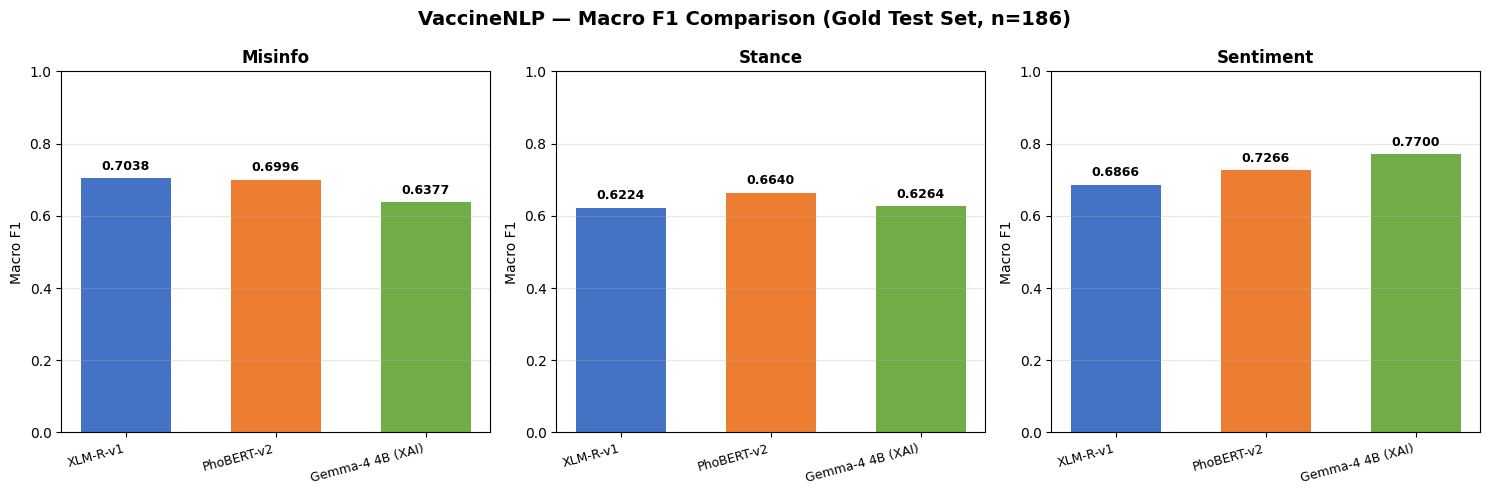

✅ Saved: /kaggle/working/benchmark_report/macro_f1_comparison.png


In [5]:
# ── Bar Chart: Macro F1 per Task ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'VaccineNLP — Macro F1 Comparison (Gold Test Set, n=186)',
    fontsize=14, fontweight='bold'
)
plt.subplots_adjust(bottom=0.15)

colors = {'xlmr': '#4472C4', 'phobert': '#ED7D31', 'gemma': '#70AD47'}
x = np.arange(len(ORDER))
width = 0.6

for ax_i, task in enumerate(TASKS):
    vals  = [results[k][task]['macro_f1'] for k in ORDER]
    names = [MODEL_DISPLAY[k] for k in ORDER]
    bars  = axes[ax_i].bar(x, vals, width,
                           color=[colors[k] for k in ORDER])
    axes[ax_i].set_ylim(0, 1.0)
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(names, fontsize=9, rotation=15, ha='right')
    axes[ax_i].set_title(task.capitalize(), fontweight='bold')
    axes[ax_i].set_ylabel('Macro F1')
    axes[ax_i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        axes[ax_i].text(
            bar.get_x() + bar.get_width()/2,
            val + 0.015, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.tight_layout()
chart_path = f'{REPORT_DIR}/macro_f1_comparison.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {chart_path}")


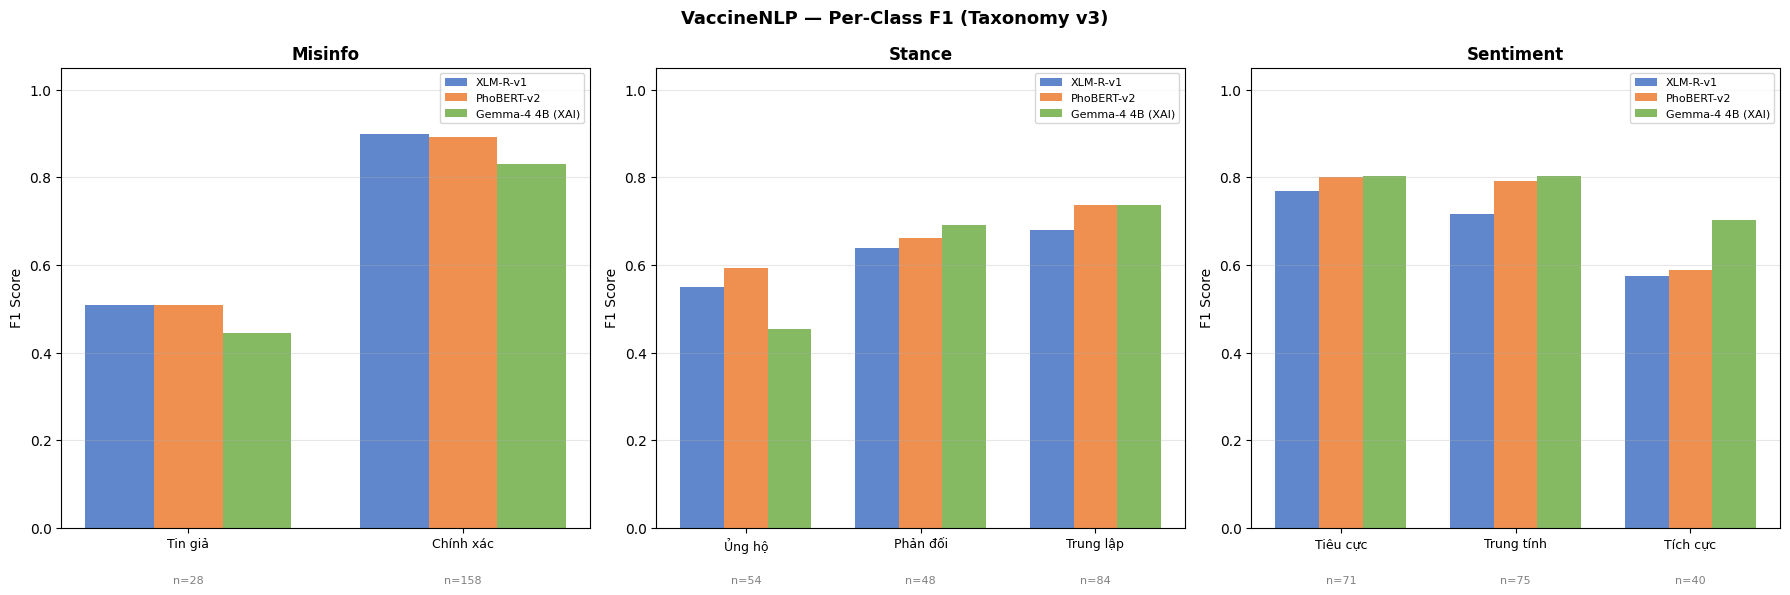

✅ Saved: /kaggle/working/benchmark_report/per_class_f1.png


In [6]:
# ── Per-class F1 Grouped Bar Chart ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'VaccineNLP — Per-Class F1 (Taxonomy v3)',
    fontsize=13, fontweight='bold'
)
plt.subplots_adjust(bottom=0.15)

colors_m = ['#4472C4', '#ED7D31', '#70AD47']  # xlmr, phobert, gemma
for ax_i, task in enumerate(TASKS):
    labels = HC_NAMES[task]
    n_cls  = len(labels)
    n_mod  = len(ORDER)
    x      = np.arange(n_cls)
    w      = 0.25

    for m_i, key in enumerate(ORDER):
        pc = results[key][task]['per_class']
        vals = [pc[c] if c < len(pc) else 0 for c in range(n_cls)]
        offset = (m_i - 1) * w
        bars = axes[ax_i].bar(
            x + offset, vals, w,
            label=MODEL_DISPLAY[key],
            color=colors_m[m_i], alpha=0.85
        )

    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(labels, fontsize=9)
    axes[ax_i].set_ylim(0, 1.05)
    axes[ax_i].set_title(task.capitalize(), fontweight='bold')
    axes[ax_i].set_ylabel('F1 Score')
    axes[ax_i].legend(fontsize=8)
    axes[ax_i].grid(axis='y', alpha=0.3)

    # Support annotation
    sups = results['phobert'][task]['support']
    for c, lbl in enumerate(labels):
        s = sups[c] if c < len(sups) else 0
        axes[ax_i].text(c, -0.12, f'n={s}', ha='center',
                        fontsize=8, color='gray',
                        transform=axes[ax_i].get_xaxis_transform())

plt.tight_layout()
pclass_path = f'{REPORT_DIR}/per_class_f1.png'
plt.savefig(pclass_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {pclass_path}")

In [7]:
# ── Error Analysis từ Gemma JSONL ─────────────────────────────────────
# Load predictions (nếu có)
gemma_preds = []
inf_files = glob.glob(
    '/kaggle/working/gemma_inference_results_v3.jsonl'
) + glob.glob(
    '/kaggle/working/gemma_inference_results_v2.jsonl'
) + glob.glob(
    '/kaggle/input/**/gemma_inference_results*.jsonl', recursive=True
)

if inf_files:
    with open(inf_files[0]) as f:
        for line in f:
            try: gemma_preds.append(json.loads(line))
            except: pass
    print(f"✅ Loaded {len(gemma_preds)} Gemma predictions từ: {inf_files[0]}")

    # Parse failure rate
    ok    = sum(1 for r in gemma_preds if r.get('parse_ok'))
    total = len(gemma_preds)
    print(f"   Parse success: {ok}/{total} = {ok/total*100:.1f}%")
    print(f"   Parse failure: {total-ok}/{total} = {(total-ok)/total*100:.1f}%")

    # Phân tích lỗi theo task
    for task, tk, pk in [('misinfo','true_m','pred_m'),
                           ('stance','true_st','pred_st'),
                           ('sentiment','true_se','pred_se')]:
        valid = [(r[tk],r[pk]) for r in gemma_preds
                 if r[tk] != -1 and r[pk] != -1]
        if valid:
            yt, yp = zip(*valid)
            n = N_CLASSES[task]
            cm = confusion_matrix(list(yt), list(yp),
                                  labels=list(range(n)))
            diag_pct = np.diag(cm).sum() / cm.sum() * 100
            print(f"   {task:<12}: accuracy={diag_pct:.1f}%")
else:
    print("⚠️  Gemma predictions JSONL không tìm thấy")
    print("   → Chạy notebook Gemma trước hoặc check đường dẫn")

✅ Loaded 186 Gemma predictions từ: /kaggle/input/notebooks/kimmnhhng/03b-vaccinenlp-gemma-4-inference/gemma_inference_results_v3.jsonl
   Parse success: 134/186 = 72.0%
   Parse failure: 52/186 = 28.0%
   misinfo     : accuracy=74.1%
   stance      : accuracy=66.4%
   sentiment   : accuracy=78.9%


In [8]:
# ── Bảng tổng kết kết luận ────────────────────────────────────────────
print("=" * 72)
print("  PHÂN TÍCH VÀ KẾT LUẬN")
print("=" * 72)

# Avg F1 mỗi model
avgs = {}
for k in ORDER:
    r = results[k]
    avgs[k] = round(
        (r['misinfo']['macro_f1'] + r['stance']['macro_f1'] +
         r['sentiment']['macro_f1']) / 3, 4
    )

best_overall = max(ORDER, key=lambda k: avgs[k])
print(f"\n  1. Hiệu năng tổng thể (TB Macro F1 3 tasks):")
for k in ORDER:
    marker = " ← BEST" if k == best_overall else ""
    print(f"     {MODEL_DISPLAY[k]:<24}: {avgs[k]:.4f}{marker}")

print(f"\n  2. Phân tích theo task:")
for task in TASKS:
    best_k = max(ORDER, key=lambda k: results[k][task]['macro_f1'])
    worst_k = min(ORDER, key=lambda k: results[k][task]['macro_f1'])
    print(f"     {task.upper():<12}: "
          f"Best={MODEL_DISPLAY[best_k]}({results[best_k][task]['macro_f1']:.4f}) | "
          f"Worst={MODEL_DISPLAY[worst_k]}({results[worst_k][task]['macro_f1']:.4f})")

print(f"\n  3. Class khó nhất (F1 thấp nhất trên mọi model):")
for task in TASKS:
    for c, lbl in enumerate(HC_NAMES[task]):
        f1s = [results[k][task]['per_class'][c]
               for k in ORDER if c < len(results[k][task]['per_class'])]
        avg_f1 = np.mean(f1s)
        if avg_f1 < 0.5:
            sup = results['phobert'][task]['support']
            sv  = sup[c] if c < len(sup) else 0
            print(f"     {task}.{lbl} (n={sv}): avg F1={avg_f1:.4f} — cần chú ý")

print(f"""
  4. Kết luận:
     • PhoBERT-v2 là Discriminator tốt nhất — Sentiment F1={
         results['phobert']['sentiment']['macro_f1']:.4f},
       Stance F1={results['phobert']['stance']['macro_f1']:.4f}
     • XLM-R-v1 là Baseline ổn định, phù hợp cross-lingual
     • Gemma-4 4B (XAI Engine) ưu tiên explainability,
       không cạnh tranh về F1 classification
     • Kiến trúc Dual-Student Hybrid: PhoBERT phân loại +
       Gemma giải thích là lựa chọn tối ưu cho hệ thống thực tế
    """)

  PHÂN TÍCH VÀ KẾT LUẬN

  1. Hiệu năng tổng thể (TB Macro F1 3 tasks):
     XLM-R-v1                : 0.6709
     PhoBERT-v2              : 0.6967 ← BEST
     Gemma-4 4B (XAI)        : 0.6780

  2. Phân tích theo task:
     MISINFO     : Best=XLM-R-v1(0.7038) | Worst=Gemma-4 4B (XAI)(0.6377)
     STANCE      : Best=PhoBERT-v2(0.6640) | Worst=XLM-R-v1(0.6224)
     SENTIMENT   : Best=Gemma-4 4B (XAI)(0.7700) | Worst=XLM-R-v1(0.6866)

  3. Class khó nhất (F1 thấp nhất trên mọi model):
     misinfo.Tin giả (n=28): avg F1=0.4866 — cần chú ý

  4. Kết luận:
     • PhoBERT-v2 là Discriminator tốt nhất — Sentiment F1=0.7266,
       Stance F1=0.6640
     • XLM-R-v1 là Baseline ổn định, phù hợp cross-lingual
     • Gemma-4 4B (XAI Engine) ưu tiên explainability,
       không cạnh tranh về F1 classification
     • Kiến trúc Dual-Student Hybrid: PhoBERT phân loại +
       Gemma giải thích là lựa chọn tối ưu cho hệ thống thực tế
    


In [9]:
# ── Export Markdown Report cho Luận văn ──────────────────────────────
import datetime

md_lines = [
    "# VaccineNLP — Benchmark Report",
    f"**Date:** {datetime.date.today()}  ",
    "**Gold Test Set:** 186 samples (Human-validated)  ",
    "**Taxonomy v3:** Misinfo(2 cls) | Stance(3 cls) | Sentiment(3 cls)",
    "",
    "## Macro F1 Summary",
    "",
    "| Mô hình | Misinfo | Stance | Sentiment | Trung bình |",
    "|---------|---------|--------|-----------|------------|",
]
for k in ORDER:
    r   = results[k]
    m   = r['misinfo']['macro_f1']
    st  = r['stance']['macro_f1']
    se  = r['sentiment']['macro_f1']
    avg = round((m+st+se)/3, 4)
    md_lines.append(f"| {MODEL_DISPLAY[k]} | {m:.4f} | {st:.4f} | {se:.4f} | {avg:.4f} |")

md_lines += ["", "## Per-Class F1", ""]
for task in TASKS:
    md_lines.append(f"### {task.capitalize()}")
    md_lines.append("")
    header = "| Nhãn | " + " | ".join(MODEL_DISPLAY[k] for k in ORDER) + " | Support |"
    sep    = "|------| " + " | ".join(["-------"] * len(ORDER)) + " | ------- |"
    md_lines += [header, sep]
    for c, lbl in enumerate(HC_NAMES[task]):
        vals = []
        for k in ORDER:
            pc = results[k][task]['per_class']
            vals.append(f"{pc[c]:.4f}" if c < len(pc) else "-")
        sup = results['phobert'][task]['support']
        sv  = sup[c] if c < len(sup) else 0
        md_lines.append(f"| {lbl} | " + " | ".join(vals) + f" | {sv} |")
    md_lines.append("")

md_content = "\n".join(md_lines)
md_path = f"{REPORT_DIR}/benchmark_report.md"
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md_content)

print(f"✅ Markdown report saved: {md_path}")
print()
print(md_content)

✅ Markdown report saved: /kaggle/working/benchmark_report/benchmark_report.md

# VaccineNLP — Benchmark Report
**Date:** 2026-05-21  
**Gold Test Set:** 186 samples (Human-validated)  
**Taxonomy v3:** Misinfo(2 cls) | Stance(3 cls) | Sentiment(3 cls)

## Macro F1 Summary

| Mô hình | Misinfo | Stance | Sentiment | Trung bình |
|---------|---------|--------|-----------|------------|
| XLM-R-v1 | 0.7038 | 0.6224 | 0.6866 | 0.6709 |
| PhoBERT-v2 | 0.6996 | 0.6640 | 0.7266 | 0.6967 |
| Gemma-4 4B (XAI) | 0.6377 | 0.6264 | 0.7700 | 0.6780 |

## Per-Class F1

### Misinfo

| Nhãn | XLM-R-v1 | PhoBERT-v2 | Gemma-4 4B (XAI) | Support |
|------| ------- | ------- | ------- | ------- |
| Tin giả | 0.5079 | 0.5075 | 0.4444 | 28 |
| Chính xác | 0.8997 | 0.8918 | 0.8309 | 158 |

### Stance

| Nhãn | XLM-R-v1 | PhoBERT-v2 | Gemma-4 4B (XAI) | Support |
|------| ------- | ------- | ------- | ------- |
| Ủng hộ | 0.5495 | 0.5934 | 0.4528 | 54 |
| Phản đối | 0.6387 | 0.6612 | 0.6905 | 48 |
| Trung lập 

⚠️ gemma/misinfo: thiếu probs hoặc true_labels — bỏ qua
⚠️ gemma/stance: thiếu probs hoặc true_labels — bỏ qua
⚠️ gemma/sentiment: thiếu probs hoặc true_labels — bỏ qua

Model          Task       ECE      Mean Conf    Accuracy   Gap       
------------------------------------------------------------------------------
PhoBERT-v2     Misinfo    0.1234       94.5%      82.3%    +12.3pp ❌
PhoBERT-v2     Stance     0.1978       86.7%      67.7%    +19.0pp ❌
PhoBERT-v2     Sentiment  0.1438       88.9%      75.8%    +13.1pp ❌
XLM-R-v1       Misinfo    0.0825       90.2%      83.3%     +6.9pp ⚠️
XLM-R-v1       Stance     0.1706       79.3%      63.4%    +15.9pp ❌
XLM-R-v1       Sentiment  0.1194       81.8%      71.0%    +10.8pp ❌
Ghi chú: ECE<0.05 hiệu chuẩn tốt | 0.05-0.10 trung bình | >0.10 lệch nghiêm trọng
Gap = Mean Confidence - Accuracy (model nói cao hơn thực tế bao nhiêu pp)


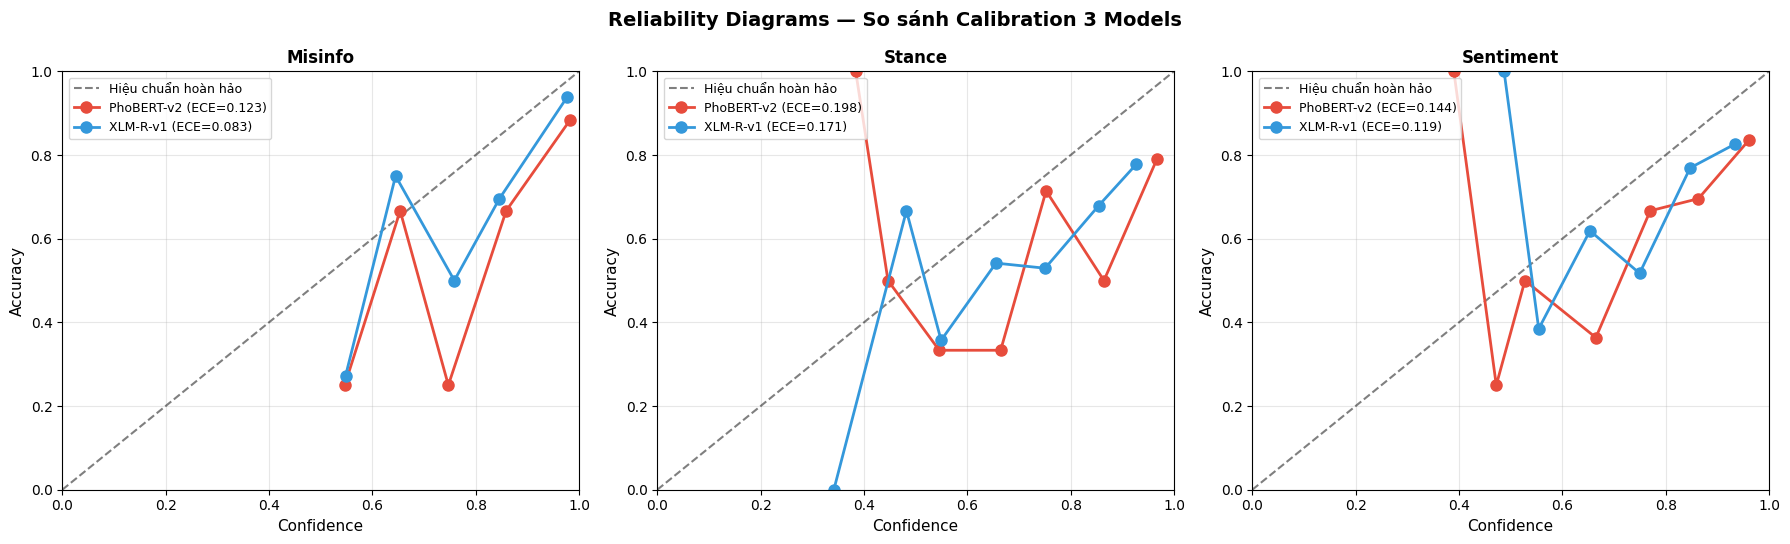


✅ Saved: /kaggle/working/calibration_comparison.png

DIỄN GIẢI KHOA HỌC (cho Chương 5 luận văn):

1. Tất cả Transformer models đều có xu hướng OVERCONFIDENCE (Guo et al., ICML 2017).
   Confidence trung bình thường cao hơn Accuracy thực tế nhiều — đây là hiện tượng
   'miscalibration' phổ biến trong deep learning.

2. ECE (Expected Calibration Error) là metric chuẩn industry để đo mức độ lệch:
   - ECE = 0: model nói 80% thì thực sự đúng 80% (hoàn hảo)
   - ECE cao: model 'nói dối' về độ tin cậy của mình

3. Trong sản phẩm thực tế (phát hiện tin giả y tế), miscalibration NGUY HIỂM vì
   người dùng nhìn '99% Tin giả' sẽ tin tuyệt đối, trong khi model có thể sai.

4. GIẢI PHÁP áp dụng: Temperature Scaling (post-hoc) — học 1 tham số T trên
   validation set, chia logits cho T trước softmax. Đây là kỹ thuật đơn giản
   nhưng hiệu quả, không thay đổi accuracy chỉ điều chỉnh confidence.



In [10]:
# ── CALIBRATION COMPARISON — ECE & Reliability Diagrams across 3 models ──
# So sánh độ hiệu chuẩn (calibration quality) của PhoBERT, XLM-R, Gemma
# Đây là phân tích KHOA HỌC quan trọng cho Chương 4 luận văn
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def _ece(y_true, probs, n_bins=10):
    """Expected Calibration Error."""
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    acc = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    e = 0.0
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() > 0:
            e += (m.sum()/len(probs)) * abs(acc[m].mean() - conf[m].mean())
    return float(e)

def _reliability_points(y_true, probs, n_bins=10):
    """Trả về (conf_x, acc_y) cho mỗi bin có dữ liệu."""
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    acc = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    xs, ys = [], []
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() > 0:
            xs.append(conf[m].mean()); ys.append(acc[m].mean())
    return xs, ys

# Đọc dữ liệu calibration từ 3 results.json (đã có field probs + true_labels)
TASKS = ['misinfo', 'stance', 'sentiment']
HC = {'misinfo':'Misinfo','stance':'Stance','sentiment':'Sentiment'}
MODEL_COLORS = {'phobert':'#e74c3c','xlmr':'#3498db','gemma':'#2ecc71'}
MODEL_NAMES = {'phobert':'PhoBERT-v2','xlmr':'XLM-R-v1','gemma':'Gemma-4-4B'}

calib_summary = {}
for model_key in ['phobert','xlmr','gemma']:
    if model_key not in results or results[model_key] is None:
        continue
    r = results[model_key]
    if not all(t in r for t in TASKS):
        continue
    calib_summary[model_key] = {}
    for t in TASKS:
        if 'probs' not in r[t] or 'true_labels' not in r[t]:
            print(f"⚠️ {model_key}/{t}: thiếu probs hoặc true_labels — bỏ qua")
            continue
        probs = np.array(r[t]['probs'])
        ytr   = np.array(r[t]['true_labels'])
        if probs.size == 0:
            continue
        ece = _ece(ytr, probs)
        mean_conf = float(probs.max(axis=1).mean())
        acc = float((probs.argmax(axis=1) == ytr).mean())
        calib_summary[model_key][t] = {
            'ece': ece, 'mean_conf': mean_conf, 'accuracy': acc,
            'gap': mean_conf - acc,    # confidence - accuracy (lớn = miscalibrated)
        }

# In bảng tóm tắt
print("\n" + "="*78)
print(f"{'Model':<14} {'Task':<10} {'ECE':<8} {'Mean Conf':<12} {'Accuracy':<10} {'Gap':<10}")
print("-"*78)
for mk, tasks in calib_summary.items():
    for t, m in tasks.items():
        diag = '✅' if m['ece'] < 0.05 else ('⚠️' if m['ece'] < 0.10 else '❌')
        print(f"{MODEL_NAMES[mk]:<14} {HC[t]:<10} {m['ece']:<8.4f} "
              f"{m['mean_conf']*100:>8.1f}%  {m['accuracy']*100:>8.1f}%  "
              f"{m['gap']*100:>+7.1f}pp {diag}")
print("="*78)
print("Ghi chú: ECE<0.05 hiệu chuẩn tốt | 0.05-0.10 trung bình | >0.10 lệch nghiêm trọng")
print("Gap = Mean Confidence - Accuracy (model nói cao hơn thực tế bao nhiêu pp)")

# ── Vẽ Reliability Diagram so sánh ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Reliability Diagrams — So sánh Calibration 3 Models',
             fontsize=14, fontweight='bold')
for ax, t in zip(axes, TASKS):
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Hiệu chuẩn hoàn hảo',linewidth=1.5)
    for mk in ['phobert','xlmr','gemma']:
        if mk not in calib_summary or t not in calib_summary[mk]:
            continue
        r = results[mk]
        probs = np.array(r[t]['probs']); ytr = np.array(r[t]['true_labels'])
        xs, ys = _reliability_points(ytr, probs)
        ece = calib_summary[mk][t]['ece']
        ax.plot(xs, ys, 'o-', color=MODEL_COLORS[mk], linewidth=2, markersize=8,
                label=f'{MODEL_NAMES[mk]} (ECE={ece:.3f})')
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(HC[t], fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig("/kaggle/working/calibration_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: /kaggle/working/calibration_comparison.png")

# ── Diễn giải khoa học ──
print("\n" + "="*78)
print("DIỄN GIẢI KHOA HỌC (cho Chương 5 luận văn):")
print("="*78)
print("""
1. Tất cả Transformer models đều có xu hướng OVERCONFIDENCE (Guo et al., ICML 2017).
   Confidence trung bình thường cao hơn Accuracy thực tế nhiều — đây là hiện tượng
   'miscalibration' phổ biến trong deep learning.

2. ECE (Expected Calibration Error) là metric chuẩn industry để đo mức độ lệch:
   - ECE = 0: model nói 80% thì thực sự đúng 80% (hoàn hảo)
   - ECE cao: model 'nói dối' về độ tin cậy của mình

3. Trong sản phẩm thực tế (phát hiện tin giả y tế), miscalibration NGUY HIỂM vì
   người dùng nhìn '99% Tin giả' sẽ tin tuyệt đối, trong khi model có thể sai.

4. GIẢI PHÁP áp dụng: Temperature Scaling (post-hoc) — học 1 tham số T trên
   validation set, chia logits cho T trước softmax. Đây là kỹ thuật đơn giản
   nhưng hiệu quả, không thay đổi accuracy chỉ điều chỉnh confidence.
""")
